# Speech / Silence Segmentation — Histogram-based Thresholding

**Author:** Phan Thanh Duy (ID 102240130)

**Goal.** Find the start and end boundaries of the speech part of a recording (i.e. separate speech from the leading / trailing silence). Two short-time features are compared with thresholds that are learned automatically from the **histograms** of a training set.

### Notebook outline

| # | Section | Content |
|---|---------|---------|
| 1 | Setup | imports, global parameters |
| 2 | Data I/O | read `.wav` signals and `.lab` annotations |
| 3 | Feature extraction | framing, smoothing, STE, spectral centroid |
| 4 | Histogram thresholds | histogram → peaks $M_1$, $M_2$ → threshold $T$ |
| 5 | Segmentation | frame decision, hangover, short-silence filling, boundaries |
| 6 | Evaluation | boundary errors (MAE / RMSE), offset learning |
| 7 | Visualization | histogram figure, per-file result plot |
| 8 | Train / test routines | grid search and evaluation loops |
| 9 | Run | train → histogram figure → test → summary table |

### Method at a glance
1. Cut each signal into 25 ms frames every 10 ms; compute **STE** and **Spectral Centroid (SC)** per frame, normalize both to $[0, 1]$ and smooth them over time.
2. Pool all training frames, build one histogram per feature, smooth it, and take its first two peaks: $M_1$ (typically the silence / noise mode) and $M_2$ (typically the speech mode).
3. Threshold: $T = \dfrac{W\,M_1 + M_2}{W + 1}$.
4. A frame is *speech* if (STE > T1 **and** SC > T2) **or** STE > T1_high.
5. Post-process (hangover, fill short silences, shrink, learned offsets) to get the speech segments.
6. A grid search on the training set selects $W$ (for STE and SC), T1_high, hangover and shrink that minimize the mean boundary MAE.

## 1. Setup

### 1.1 Imports
Standard library, NumPy for numerics, Matplotlib for plots, SciPy only for reading `.wav` files.

In [1]:
# ---- Standard library ----
import glob
import os
import warnings

# ---- Scientific stack ----
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile

### 1.2 Global parameters
All tunable constants live here. The `*_GRID` lists define the search space explored during training.

In [2]:
# =====================================================================
# GLOBAL PARAMETERS
# =====================================================================

# --- Framing ---
FRAME_MS = 25          # frame length (ms)
SHIFT_MS = 10          # frame shift (ms)
MIN_SILENCE_MS = 200   # silences shorter than this (between two speech parts) are filled

# --- Histogram analysis ---
HIST_BINS = 100        # number of histogram bins
HIST_SMOOTH_LEN = 5    # moving-average length for the histogram (odd number)
TIME_SMOOTH_LEN = 5    # moving-average length for feature contours over time (odd number)
PEAK_RATIO = 0.05      # a peak counts only if it reaches >= 5% of the highest histogram value

# --- Grid-search ranges (used in train) ---
W_GRID = [0.5, 1, 2, 3, 5, 8, 10, 15, 20]   # weight W in T = (W*M1 + M2) / (W + 1)
T_HIGH_GRID = [0.05, 0.1, 0.2, 0.4, 1.0]    # high-energy override threshold (1.0 = disabled)
H_GRID = [0, 1, 2, 3, 5]                    # hangover length (frames)
SHRINK_GRID = [-3, -2, -1, 0, 1, 2, 3, 4]   # extra boundary shrink (frames; negative = extend)

# --- Labels and data folders ---
SPEECH_LABELS = {'v', 'uv'}   # .lab labels treated as speech (voiced / unvoiced)

# Folder of this script; notebooks have no __file__, so fall back to the working directory
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
TRAIN_DIR = "TinHieuHuanLuyen"   # folder with training .wav + .lab files
TEST_DIR = "TinHieuKiemThu"      # folder with test .wav + .lab files

## 2. Data I/O
Helpers to locate the data folders, read a `.wav` signal (mono, scaled to about $[-1, 1)$) and read the ground-truth speech segments from the matching `.lab` file.

In [ ]:
def find_data_dir(name):
    """Locate a data folder by searching a few likely base directories.

    Args:
        name (str): Folder name to look for (e.g. "TinHieuHuanLuyen").

    Returns:
        str: Full path of the first existing match. If nothing is found, `name`
        is returned unchanged so the caller can report "no files found".
    """
    # Candidate base folders: this file's folder, its parent, cwd, cwd's parent
    candidates = [BASE_DIR, os.path.dirname(BASE_DIR), os.getcwd(), os.path.dirname(os.getcwd())]

    # Return the first candidate that really contains the folder
    for base in candidates:
        path = os.path.join(base, name)
        if os.path.isdir(path):
            return path

    # Not found: fall back to the bare name
    return name


def read_wav(path):
    """Read a WAV file as a mono float signal.

    Args:
        path (str): Path to the `.wav` file.

    Returns:
        tuple[np.ndarray, int]: `(x, fs)` where `x` is a 1-D float64 signal
        (integer PCM is scaled to about [-1, 1)) and `fs` is the sampling rate in Hz.
    """
    # Read the file (silence scipy's warnings about non-audio chunks)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fs, x = wavfile.read(path)

    # Multi-channel -> mono by averaging channels
    if x.ndim > 1:
        x = x.mean(axis=1)

    # Integer PCM -> float in [-1, 1)
    if np.issubdtype(x.dtype, np.integer):
        x = x / float(np.iinfo(x.dtype).max + 1)

    return x.astype(np.float64), fs


def read_lab(lab_path, speech_labels=SPEECH_LABELS):
    """Read ground-truth speech segments from a `.lab` annotation file.

    Each line has the form `start end label` (times in seconds). Only lines whose
    label is in `speech_labels` are kept, and back-to-back speech lines are merged
    into one segment.

    Args:
        lab_path (str): Path to the `.lab` file.
        speech_labels (set[str]): Labels counted as speech (default: SPEECH_LABELS).

    Returns:
        list[list[float]]: Speech segments `[[start_s, end_s], ...]` in seconds;
        an empty list if the file does not exist.
    """
    segs = []

    # No annotation file -> no ground truth
    if not os.path.exists(lab_path):
        return segs

    with open(lab_path, 'r') as f:
        for line in f:
            p = line.strip().split()
            # Keep only well-formed lines with a speech label
            if len(p) >= 3 and p[2].lower() in speech_labels:
                s, e = float(p[0]), float(p[1])
                # Merge with the previous segment if they touch (e.g. 'v' followed by 'uv')
                if segs and abs(segs[-1][1] - s) < 1e-9:
                    segs[-1][1] = e
                else:
                    segs.append([s, e])
    return segs

## 3. Feature extraction
Each frame is described by two features, both divided by their maximum over the file so that they lie in $[0, 1]$:

- **STE** (short-time energy) $=\frac{1}{L}\sum_{n} x[n]^2$ — high for speech, low for silence.

- **SC** (spectral centroid) $=\dfrac{\sum_k k\,|X[k]|}{\sum_k |X[k]|}$ — the "centre of mass" of the frame spectrum; it complements STE.

The DFT used for SC is computed directly with a cosine / sine matrix product (no FFT).

### 3.1 Framing and smoothing helpers

In [ ]:
def create_frames(signal, fs, frame_ms=FRAME_MS, shift_ms=SHIFT_MS):
    """Cut a signal into overlapping frames (no padding).

    Args:
        signal (np.ndarray): 1-D signal.
        fs (int): Sampling rate in Hz.
        frame_ms (float): Frame length in ms (default: FRAME_MS).
        shift_ms (float): Frame shift in ms (default: SHIFT_MS).

    Returns:
        np.ndarray: Matrix of shape `(n_frames, frame_len)`; frame `i` covers samples
        `[i*shift, i*shift + frame_len)`. Trailing samples that cannot fill a frame are dropped.
    """
    # Frame length and shift in samples
    L = int(round(frame_ms * fs / 1000))
    S = int(round(shift_ms * fs / 1000))

    # Number of complete frames
    n = (len(signal) - L) // S + 1

    # Index matrix: row i = [i*S, i*S + 1, ..., i*S + L - 1]
    idx = np.arange(L)[None, :] + S * np.arange(n)[:, None]
    return signal[idx]


def moving_average(x, length):
    """Moving-average filter with edge replication (same output length for odd `length`).

    Args:
        x (array-like): 1-D input.
        length (int): Window length; use an odd number to keep the output length equal to `len(x)`.

    Returns:
        np.ndarray: Smoothed signal.
    """
    x = np.asarray(x, dtype=np.float64)
    h = length // 2

    # Pad both ends by repeating the first / last value
    padded = np.concatenate([np.full(h, x[0]), x, np.full(h, x[-1])])

    # Window sums via cumulative sum, then divide by the window length
    csum = np.concatenate([[0.0], np.cumsum(padded)])
    return (csum[length:] - csum[:-length]) / length

### 3.2 Short-time energy and spectral centroid

In [ ]:
def compute_ste(frames):
    # Mean of squared samples in each frame
    ste = np.mean(frames ** 2, axis=1)

    # Normalize by the largest value
    m = np.max(ste)
    return ste / m if m > 0 else ste


def dft_magnitude_half(frames):
    """Magnitude of the first half of the DFT of each frame (matrix form, rectangular window).

    Args:
        frames (np.ndarray): Frame matrix `(n_frames, N)`.

    Returns:
        np.ndarray: Magnitudes `|X[k]|`, k = 0 .. N/2 - 1, shape `(n_frames, N // 2)`.
    """
    N = frames.shape[1]
    n = np.arange(N)[:, None]        # time index (column)
    k = np.arange(N // 2)[None, :]   # frequency-bin index (row)

    # Real and imaginary parts as matrix products with cos / sin kernels
    ang = 2 * np.pi * n * k / N
    re = frames @ np.cos(ang)
    im = frames @ np.sin(ang)

    return np.sqrt(re ** 2 + im ** 2)


def compute_spectral_centroid(frames):
    # Magnitude spectrum and bin indices 1 .. N/2
    X = dft_magnitude_half(frames)
    k = np.arange(1, X.shape[1] + 1)[None, :]

    # Weighted mean of bin index (guard against division by zero)
    s = np.sum(X, axis=1)
    sc = np.where(s > 0, np.sum(k * X, axis=1) / np.where(s > 0, s, 1), 0.0)

    # Normalize by the largest value
    m = np.max(sc)
    return sc / m if m > 0 else sc

### 3.3 Full feature pipeline for one file
Read → frame → STE / SC → smooth over time. Both raw (`ste`, `sc`) and smoothed (`ste_s`, `sc_s`) contours are kept for plotting; the smoothed ones drive the decisions.

In [6]:
def extract_smoothed_features(path):
    """Extract raw and time-smoothed STE / SC contours from a WAV file.

    Args:
        path (str): Path to the `.wav` file.

    Returns:
        dict: `signal` (waveform), `fs` (Hz), `ste` / `sc` (raw features per frame),
        `ste_s` / `sc_s` (features smoothed over TIME_SMOOTH_LEN frames).
    """
    # Load and frame the signal
    signal, fs = read_wav(path)
    frames = create_frames(signal, fs)

    # Per-frame features
    ste = compute_ste(frames)
    sc = compute_spectral_centroid(frames)

    # Pack raw + smoothed contours
    return {"signal": signal, "fs": fs, "ste": ste, "sc": sc,
            "ste_s": moving_average(ste, TIME_SMOOTH_LEN),
            "sc_s": moving_average(sc, TIME_SMOOTH_LEN)}

## 4. Histogram-based thresholds
A feature histogram is usually **bimodal**: one mode for silence / noise frames, one for speech frames. After smoothing, the first two peaks $M_1 < M_2$ are located and the threshold is placed between them:

$$T = \frac{W\,M_1 + M_2}{W + 1}$$

$W = 1$ gives the midpoint; a larger $W$ moves $T$ towards $M_1$ (more permissive), a smaller $W$ towards $M_2$ (stricter).

In [7]:
def build_histogram(features, bins=HIST_BINS, lo=None, hi=None):
    """Build a fixed-width histogram of a feature.

    Args:
        features (array-like): Feature values.
        bins (int): Number of bins (default: HIST_BINS).
        lo (float | None): Lower edge; defaults to `min(features)`.
        hi (float | None): Upper edge; defaults to `max(features)`.

    Returns:
        tuple[np.ndarray, np.ndarray]: `(hist, centers)` — counts per bin and bin centres.
    """
    features = np.asarray(features)
    lo = features.min() if lo is None else lo
    hi = features.max() if hi is None else hi

    # Map each value to a bin index (clip so the maximum falls in the last bin)
    idx = np.clip(((features - lo) / (hi - lo) * bins).astype(int), 0, bins - 1)

    # Count occurrences per bin
    hist = np.zeros(bins)
    for k in idx:
        hist[k] += 1

    # Bin centres
    edges = np.linspace(lo, hi, bins + 1)
    return hist, (edges[:-1] + edges[1:]) / 2


def find_first_two_peaks(smooth_hist, centers, peak_ratio=PEAK_RATIO):
    """Find the two left-most significant peaks of a smoothed histogram.

    A bin is a peak if it is strictly higher than its left neighbour, not lower than its
    right neighbour, and at least `peak_ratio` times the highest bin.

    Args:
        smooth_hist (np.ndarray): Smoothed histogram.
        centers (np.ndarray): Bin centres (same length as `smooth_hist`).
        peak_ratio (float): Minimum peak height relative to the global maximum.

    Returns:
        tuple[float, float]: `(M1, M2)` — feature values of the first and second peak.
        Fallbacks: no peak -> M1 = first bin centre; only one peak -> M2 = M1.
    """
    # Minimum height for a bin to qualify as a peak
    min_h = peak_ratio * smooth_hist.max()

    # Scan left to right; array borders are treated as -inf neighbours
    peaks = []
    for i in range(len(smooth_hist)):
        left = smooth_hist[i - 1] if i > 0 else -np.inf
        right = smooth_hist[i + 1] if i < len(smooth_hist) - 1 else -np.inf
        if smooth_hist[i] > left and smooth_hist[i] >= right and smooth_hist[i] >= min_h:
            peaks.append(centers[i])

    # First two peaks, with fallbacks when fewer are found
    M1 = peaks[0] if len(peaks) >= 1 else centers[0]
    M2 = peaks[1] if len(peaks) >= 2 else M1
    return M1, M2


def threshold_from_peaks(M1, M2, W):
    """Weighted threshold between two histogram peaks: T = (W*M1 + M2) / (W + 1).

    Args:
        M1 (float): First (lower) peak.
        M2 (float): Second (higher) peak.
        W (float): Weight of M1 (W = 1 -> midpoint; larger W -> closer to M1).

    Returns:
        float: Threshold T.
    """
    return (W * M1 + M2) / (W + 1)


def analyze_histogram(features):
    """Histogram -> smoothing -> first two peaks, in one call.

    Args:
        features (array-like): Feature values (e.g. pooled smoothed STE of all training frames).

    Returns:
        tuple: `(M1, M2, hist, smooth, centers)` — the two peaks, raw histogram,
        smoothed histogram (HIST_SMOOTH_LEN) and bin centres.
    """
    hist, centers = build_histogram(features)
    smooth = moving_average(hist, HIST_SMOOTH_LEN)
    M1, M2 = find_first_two_peaks(smooth, centers)
    return M1, M2, hist, smooth, centers

## 5. Segmentation
Turn the frame-level features into speech segments (in seconds):

1. **Classify** each frame with the thresholds.
2. **Hangover** — dilate speech by `hang` frames so that short gaps inside words get bridged.
3. **Fill short silences** — pauses shorter than `MIN_SILENCE_MS` between two speech parts become speech.
4. **Shrink** — erode by `hang + shrink` frames (removes the hangover again; `shrink` is an extra correction).
5. **Convert** the frame mask to `[start, end]` times and add the learned start / end offsets.

### 5.1 Frame decision and mask morphology

In [8]:
def classify_frames(ste_s, sc_s, T1, T2, T1_high=1.0):
    """Frame-level speech / non-speech decision.

    Speech if (STE > T1 and SC > T2) or STE > T1_high. With the default T1_high = 1.0
    the override never triggers, because normalized STE never exceeds 1.

    Args:
        ste_s (np.ndarray): Smoothed, normalized STE per frame.
        sc_s (np.ndarray): Smoothed, normalized SC per frame.
        T1 (float): STE threshold.
        T2 (float): SC threshold.
        T1_high (float): STE level that forces "speech" regardless of SC.

    Returns:
        np.ndarray: Boolean mask, True = speech.
    """
    return ((ste_s > T1) & (sc_s > T2)) | (ste_s > T1_high)


def extend_speech(is_speech, h):
    """Dilate the speech mask: a frame becomes speech if any frame within +/- h is speech.

    Args:
        is_speech (np.ndarray): Boolean speech mask.
        h (int): Half-window in frames (h <= 0 returns an unchanged copy).

    Returns:
        np.ndarray: Dilated boolean mask.
    """
    # Nothing to do for a non-positive extension
    if h <= 0:
        return is_speech.copy()

    # Zero-pad, then count speech frames in every (2h+1)-wide window via cumulative sum
    x = is_speech.astype(int)
    padded = np.concatenate([np.zeros(h, dtype=int), x, np.zeros(h, dtype=int)])
    csum = np.concatenate([[0], np.cumsum(padded)])
    window_sum = csum[2 * h + 1:] - csum[:-(2 * h + 1)]

    # Speech if at least one speech frame is inside the window
    return window_sum > 0


def shrink_speech(is_speech, n):
    """Shrink (erode) or, for negative `n`, extend the speech mask by |n| frames on each side.

    Args:
        is_speech (np.ndarray): Boolean speech mask.
        n (int): > 0 erodes, 0 keeps the mask, < 0 dilates by -n.

    Returns:
        np.ndarray: Modified boolean mask.
    """
    if n == 0:
        return is_speech.copy()
    if n < 0:
        return extend_speech(is_speech, -n)

    # Erosion = dilation of the complement, complemented again
    return ~extend_speech(~is_speech, n)


def fill_short_silences(is_speech, min_silence_frames):
    """Turn silence runs shorter than `min_silence_frames` into speech.

    Only runs enclosed by speech on both sides are filled; leading and trailing
    silences are left untouched.

    Args:
        is_speech (np.ndarray): Boolean speech mask.
        min_silence_frames (int): Minimum length (in frames) for a silence to be kept.

    Returns:
        np.ndarray: Boolean mask with short internal silences filled.
    """
    out = is_speech.copy()
    n, i = len(out), 0

    while i < n:
        if not out[i]:
            # Find the end j of this silence run [i, j)
            j = i
            while j < n and not out[j]:
                j += 1
            # Fill it if it is internal (speech on both sides) and short
            if i > 0 and j < n and (j - i) < min_silence_frames:
                out[i:j] = True
            i = j
        else:
            i += 1
    return out

### 5.2 From mask to time segments, and the full segmentation routine

In [9]:
def mask_to_segments(is_speech, fs):
    """Convert a frame-level speech mask into time segments.

    A frame's time is its centre; each segment spans from half a shift before the
    centre of its first frame to half a shift after the centre of its last frame.

    Args:
        is_speech (np.ndarray): Boolean speech mask (one value per frame).
        fs (int): Sampling rate in Hz.

    Returns:
        list[list[float]]: Segments `[[start_s, end_s], ...]` in seconds.
    """
    # Frame length / shift in samples, frame-centre times, half-shift in seconds
    L = int(round(FRAME_MS * fs / 1000))
    S = int(round(SHIFT_MS * fs / 1000))
    centers = (np.arange(len(is_speech)) * S + L / 2) / fs
    half = S / fs / 2

    # Walk through the mask and collect runs of True
    segs, start = [], None
    for i, v in enumerate(is_speech):
        if v and start is None:
            start = i                                   # a run begins
        elif not v and start is not None:
            segs.append([centers[start] - half, centers[i - 1] + half])   # a run ends
            start = None

    # Close a run that lasts until the last frame
    if start is not None:
        segs.append([centers[start] - half, centers[-1] + half])
    return segs


def segment_signal(feat, T1, T2, T1_high=1.0, hang=0, shrink=0, off_start=0.0, off_end=0.0):
    """Full segmentation of one file from its smoothed features.

    Pipeline: classify -> hangover (extend) -> fill short silences -> shrink by
    (hang + shrink) -> segments -> add start / end offsets.

    Args:
        feat (dict): Output of `extract_smoothed_features`.
        T1 (float): STE threshold.
        T2 (float): SC threshold.
        T1_high (float): STE level that forces "speech".
        hang (int): Hangover length in frames.
        shrink (int): Extra shrink in frames after the hangover is removed (negative = extend).
        off_start (float): Offset added to every segment start (s).
        off_end (float): Offset added to every segment end (s).

    Returns:
        tuple[np.ndarray, list[list[float]]]: `(mask, segs)` — frame mask and speech
        segments `[[start_s, end_s], ...]`; segments with end <= start are discarded.
    """
    # 1) Frame decision
    mask = classify_frames(feat["ste_s"], feat["sc_s"], T1, T2, T1_high)

    # 2) Hangover: bridge small holes inside speech
    mask = extend_speech(mask, hang)

    # 3) Fill short silences between speech parts
    mask = fill_short_silences(mask, MIN_SILENCE_MS // SHIFT_MS)

    # 4) Undo the hangover and apply the extra shrink
    mask = shrink_speech(mask, hang + shrink)

    # 5) Frames -> seconds, apply offsets, drop invalid segments
    segs = mask_to_segments(mask, feat["fs"])
    segs = [[s0 + off_start, e0 + off_end] for s0, e0 in segs if (e0 + off_end) > (s0 + off_start)]
    return mask, segs

## 6. Evaluation and offset learning
**Boundary error** is measured in both directions (each ground-truth boundary → nearest predicted one, and each predicted boundary → nearest ground-truth one) and reported as MAE and RMSE in milliseconds.

**Offset learning** estimates a systematic bias of the detected starts / ends on the training set and cancels it with a constant shift (median, so outliers matter little).

In [10]:
def boundary_errors(pred_segs, true_segs):
    """Boundary error between predicted and ground-truth segments (in ms).

    All start / end times are flattened into two lists. Errors are the distance from every
    true boundary to the nearest predicted one and vice versa, so missing and extra
    boundaries are both penalized.

    Args:
        pred_segs (list[list[float]]): Predicted segments `[[start_s, end_s], ...]`.
        true_segs (list[list[float]]): Ground-truth segments (same format).

    Returns:
        tuple[float, float]: `(MAE_ms, RMSE_ms)`. `(nan, nan)` if there is no ground truth;
        `(inf, inf)` if there is ground truth but no prediction.
    """
    # Flatten segments into boundary lists
    pred = np.array([t for sg in pred_segs for t in sg])
    true = np.array([t for sg in true_segs for t in sg])

    # Degenerate cases
    if len(true) == 0:
        return np.nan, np.nan
    if len(pred) == 0:
        return np.inf, np.inf

    # Nearest-boundary distances in both directions, converted to ms
    e1 = [np.min(np.abs(pred - t)) for t in true]
    e2 = [np.min(np.abs(true - p)) for p in pred]
    err = np.array(e1 + e2) * 1000.0

    return float(np.mean(err)), float(np.sqrt(np.mean(err ** 2)))


def learn_offsets(data, T1, T2, Th, hang, shrink):
    """Estimate constant start / end corrections from the training files.

    For every ground-truth segment, take the nearest predicted start and end and record
    the signed error (pred - truth). The offsets are the negated medians of these errors.

    Args:
        data (list[dict]): Training features; each dict has the keys of
            `extract_smoothed_features` plus `"true"` (ground-truth segments).
        T1 (float): STE threshold.
        T2 (float): SC threshold.
        Th (float): T1_high.
        hang (int): Hangover (frames).
        shrink (int): Extra shrink (frames).

    Returns:
        tuple[float, float]: `(off_start, off_end)` in seconds (0.0 if no usable data).
    """
    err_s, err_e = [], []

    for d in data:
        # Segment with zero offsets, skip files without prediction / ground truth
        _, segs = segment_signal(d, T1, T2, Th, hang, shrink)
        if not segs or not d["true"]:
            continue

        ps = np.array([sg[0] for sg in segs])   # predicted starts
        pe = np.array([sg[1] for sg in segs])   # predicted ends

        # Signed error of the nearest prediction for each ground-truth boundary
        for g0, g1 in d["true"]:
            err_s.append(ps[np.argmin(np.abs(ps - g0))] - g0)
            err_e.append(pe[np.argmin(np.abs(pe - g1))] - g1)

    # Offset = minus the median error (robust to outliers)
    off_s = -float(np.median(err_s)) if err_s else 0.0
    off_e = -float(np.median(err_e)) if err_e else 0.0
    return off_s, off_e

## 7. Visualization
- **Histogram figure** — merged and per-file histograms of STE and SC (log y-axis) with $M_1$, $M_2$ and the chosen threshold.
- **Result plot** — per test file: STE with T1, SC with T2, and the waveform with ground-truth (red) and detected (blue, dashed) boundaries.

In [11]:
def save_histogram_figure(model, out_path="huanluyen_histogram.png"):
    """Plot the training histograms with peaks and thresholds (STE left, SC right).

    Each panel shows the merged histogram (bars), one curve per training file, the smoothed
    merged histogram, the peaks M1 / M2 and the threshold T. The figure is displayed with
    `plt.show()`; `out_path` is currently unused (nothing is written to disk).

    Args:
        model (dict): Output of `train`.
        out_path (str): Intended image path (unused).

    Returns:
        None
    """
    colors = ['tab:red', 'tab:green', 'tab:purple', 'tab:orange', 'tab:brown', 'tab:pink']
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

    # One panel per feature: (axis, model key, index in per_file tuples, threshold, W, label)
    for ax, key, idx, T, W, name in [
            (axes[0], "ste", 1, model["T1"], model["W_ste"], "STE"),
            (axes[1], "sc", 2, model["T2"], model["W_sc"], "Spectral Centroid")]:
        M1, M2, hist, smooth, centers = model[key]

        # Common value range so every per-file histogram uses the same bins
        all_x = np.concatenate([p[idx] for p in model["per_file"]])
        lo, hi = all_x.min(), all_x.max()
        width = centers[1] - centers[0]

        # Merged histogram as bars (normalized to a frame ratio)
        ax.bar(centers, hist / hist.sum(), width=width, color='lightgray',
               label=f'Merged {len(model["per_file"])} files')

        # Per-file histograms as thin curves
        for j, p in enumerate(model["per_file"]):
            h, c = build_histogram(p[idx], lo=lo, hi=hi)
            ax.plot(c, h / h.sum(), color=colors[j % len(colors)], linewidth=1,
                    alpha=0.8, label=p[0])

        # Smoothed merged histogram, peaks and threshold
        ax.plot(centers, smooth / hist.sum(), color='blue', linewidth=2.5, label='Smoothed merged histogram')
        ax.axvline(M1, color='green', linestyle=':', linewidth=2.5, label=f'M1 = {M1:.3f}')
        ax.axvline(M2, color='orange', linestyle=':', linewidth=2.5, label=f'M2 = {M2:.3f}')
        ax.axvline(T, color='black', linewidth=3, label=f'Threshold T = {T:.3f} (W = {W})')

        # Axis formatting
        ax.set_yscale('log')
        ax.set_title(f"Global Threshold for {name}", fontsize=16, fontweight='bold')
        ax.set_xlabel(f"{name} Value (Normalized)", fontsize=14)
        ax.set_ylabel("Frame Ratio (Log Scale)", fontsize=14)
        ax.tick_params(labelsize=12)
        ax.legend(fontsize=10, loc='upper right')

    fig.suptitle("Determine Thresholds from Training Data Histogram", fontsize=18, fontweight='bold')
    plt.show()


def plot_result(path, feat, mask, pred, true, T1, T2, T1_high, mae, rmse):
    """Plot the segmentation result of one file in three stacked panels.

    Panels: (1) STE with threshold T1 (and T1_high if < 1), (2) SC with threshold T2,
    (3) waveform with ground-truth boundaries (red) and detected boundaries (blue, dashed).

    Args:
        path (str): File path (only its base name is shown in the title).
        feat (dict): Output of `extract_smoothed_features`.
        mask (np.ndarray): Frame-level speech mask (not drawn; kept for interface symmetry).
        pred (list[list[float]]): Detected segments `[[start_s, end_s], ...]`.
        true (list[list[float]]): Ground-truth segments.
        T1 (float): STE threshold.
        T2 (float): SC threshold.
        T1_high (float): High-energy override level (drawn only if < 1).
        mae (float): Boundary MAE in ms (shown in the title).
        rmse (float): Boundary RMSE in ms (shown in the title).

    Returns:
        None
    """
    # Time axes: waveform samples and frame centres
    sig, fs = feat["signal"], feat["fs"]
    L = int(round(FRAME_MS * fs / 1000))
    S = int(round(SHIFT_MS * fs / 1000))
    t_sig = np.arange(len(sig)) / fs
    t_fr = (np.arange(len(feat["ste"])) * S + L / 2) / fs

    fig, ax = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)

    # Panel 1: short-time energy and its threshold(s)
    ax[0].plot(t_fr, feat["ste"], color='lime', linewidth=1, label='STE (original)')
    ax[0].plot(t_fr, feat["ste_s"], color='cyan', linewidth=1.5, label='STE (filtered)')
    ax[0].axhline(T1, color='black', linewidth=2.5, label=f'T1 = {T1:.3f}')
    if T1_high < 1.0:
        ax[0].axhline(T1_high, color='magenta', linestyle='--', linewidth=1.2, label=f'T1_high = {T1_high:.2f}')
    ax[0].set_xlim(0, t_sig[-1])
    ax[0].set_title("Short time energy", fontsize=10, loc="left")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Normalized STE")
    ax[0].legend(loc='lower right', bbox_to_anchor=(1.0, 1.0), ncol=4, fontsize=7, frameon=False)

    # Panel 2: spectral centroid and its threshold
    ax[1].plot(t_fr, feat["sc"], color='lime', linewidth=1, label='SC (original)')
    ax[1].plot(t_fr, feat["sc_s"], color='cyan', linewidth=1.5, label='SC (filtered)')
    ax[1].axhline(T2, color='black', linewidth=2.5, label=f'T2 = {T2:.3f}')
    ax[1].set_xlim(0, t_sig[-1])
    ax[1].set_title("Spectral centroid", fontsize=10, loc="left")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Normalized SC")
    ax[1].legend(loc='lower right', bbox_to_anchor=(1.0, 1.0), ncol=4, fontsize=7, frameon=False)

    # Panel 3: waveform, STE overlay, ground-truth and detected boundaries
    ax[2].plot(t_sig, sig, color='silver', label='Waveform')
    ax[2].plot(t_fr, feat["ste_s"] * np.max(np.abs(sig)), color='green', linewidth=1.5, label='STE overlay')
    for k, (s0, e0) in enumerate(true):
        ax[2].axvline(s0, color='red', linewidth=1.5, label='Groundtruth' if k == 0 else None)
        ax[2].axvline(e0, color='red', linewidth=1.5)
    for k, (s0, e0) in enumerate(pred):
        ax[2].axvline(s0, color='blue', linestyle='--', linewidth=1.5, label='Algorithm' if k == 0 else None)
        ax[2].axvline(e0, color='blue', linestyle='--', linewidth=1.5)
    ax[2].set_xlim(0, t_sig[-1])
    ax[2].set_title("Signal and boundaries", fontsize=10, loc="left")
    ax[2].set_xlabel("Time (s)")
    ax[2].set_ylabel("Amplitude")
    ax[2].legend(loc='lower right', bbox_to_anchor=(1.0, 1.0), ncol=4, fontsize=7, frameon=False)

    # Figure title with the error of this file
    base_name = os.path.basename(path)
    fig.suptitle(f"{base_name} | MAE = {mae:.2f} ms | RMSE = {rmse:.2f} ms", fontsize=11, fontweight='bold')
    plt.show()

## 8. Training and testing routines
**`train`**
1. Load every training `.wav` with its `.lab`.
2. Pool all smoothed STE / SC values → histograms → peaks $M_1$, $M_2$.
3. Grid search over $(W_{STE}, W_{SC}, T1_{high}, hang, shrink)$, minimizing the mean per-file MAE.
4. Learn start / end offsets with the best setting and return everything in a `model` dict.

**`test_file`** applies the model to one unseen file, prints the boundaries, plots the file and returns its error figures; **`print_test_summary`** prints all results as a table.

In [12]:
def train(train_dir=None):
    """Learn thresholds and post-processing parameters from the training set.

    Args:
        train_dir (str | None): Folder with training `.wav` + `.lab` pairs; if None,
            the folder named TRAIN_DIR is searched with `find_data_dir`.

    Returns:
        dict | None: `None` if no `.wav` file is found, otherwise a model dict with keys:
            - `per_file`: list of `(file_name, ste_s, sc_s)` for plotting,
            - `train_mae`: best mean MAE on the training set (ms),
            - `T1`, `T2`: STE / SC thresholds,
            - `T1_high`, `hang`, `shrink`: best post-processing parameters,
            - `off_start`, `off_end`: learned boundary offsets (s),
            - `W_ste`, `W_sc`: best weights W for STE / SC,
            - `ste`, `sc`: tuples `(M1, M2, hist, smooth_hist, centers)` of each histogram.
    """
    # 1) Locate training files
    train_dir = train_dir or find_data_dir(TRAIN_DIR)
    files = sorted(glob.glob(os.path.join(train_dir, "*.wav")))
    if not files:
        print(f"Warning: No training files found in '{train_dir}'!")
        return None

    # 2) Extract features and ground truth for every file
    print(f"Reading {len(files)} training files from: {train_dir}")
    data = []
    for f in files:
        feat = extract_smoothed_features(f)
        feat["true"] = read_lab(f.replace(".wav", ".lab"))
        data.append(feat)

    # 3) Pooled histograms -> first two peaks (M1, M2) of STE and SC
    all_ste = np.concatenate([d["ste_s"] for d in data])
    all_sc = np.concatenate([d["sc_s"] for d in data])
    M1s, M2s, h_s, hs_s, c_s = analyze_histogram(all_ste)
    M1c, M2c, h_c, hs_c, c_c = analyze_histogram(all_sc)

    # 4) Grid search: minimize the mean per-file MAE over all parameter combinations
    print("Running grid search for optimal parameters (may take a moment)...")
    best = (np.inf, None, None, None, None, None)   # (score, Ws, Wc, Th, hang, shrink)
    for Ws in W_GRID:
        for Wc in W_GRID:
            T1 = threshold_from_peaks(M1s, M2s, Ws)
            T2 = threshold_from_peaks(M1c, M2c, Wc)
            for Th in T_HIGH_GRID:
                for hang in H_GRID:
                    for shrink in SHRINK_GRID:
                        # Mean MAE over files with finite error
                        maes = []
                        for d in data:
                            _, segs = segment_signal(d, T1, T2, Th, hang, shrink)
                            mae, _ = boundary_errors(segs, d["true"])
                            if np.isfinite(mae):
                                maes.append(mae)
                        score = np.mean(maes) if maes else np.inf
                        if score < best[0]:
                            best = (score, Ws, Wc, Th, hang, shrink)

    # 5) Final thresholds and offsets from the best setting
    _, Ws, Wc, Th, hang, shrink = best
    T1 = threshold_from_peaks(M1s, M2s, Ws)
    T2 = threshold_from_peaks(M1c, M2c, Wc)
    off_s, off_e = learn_offsets(data, T1, T2, Th, hang, shrink)

    # 6) Pack the model
    print(f"[TRAINING RESULTS] Average MAE = {best[0]:.2f} ms")
    per_file = [(os.path.basename(f), d["ste_s"], d["sc_s"]) for f, d in zip(files, data)]
    return {"per_file": per_file, "train_mae": float(best[0]), "T1": T1, "T2": T2,
            "T1_high": Th, "hang": hang, "shrink": shrink, "off_start": off_s,
            "off_end": off_e, "W_ste": Ws, "W_sc": Wc,
            "ste": (M1s, M2s, h_s, hs_s, c_s), "sc": (M1c, M2c, h_c, hs_c, c_c)}


def test_file(model, wav_path):
    """Evaluate a trained model on ONE test file (prints boundaries, plots the file).

    Args:
        model (dict): Output of `train`.
        wav_path (str): Path to the test `.wav`; the ground truth is read from the `.lab`
            file with the same name.

    Returns:
        tuple: `(file_name, n_gt_bounds, n_pred_bounds, mae_ms, rmse_ms)`.
    """
    # 1) Features -> segmentation with the trained parameters
    feat = extract_smoothed_features(wav_path)
    mask, pred = segment_signal(feat, model["T1"], model["T2"], model["T1_high"], model["hang"],
                                model.get("shrink", 0),
                                model.get("off_start", 0.0),
                                model.get("off_end", 0.0))

    # 2) Compare with the ground truth
    true = read_lab(wav_path.replace(".wav", ".lab"))
    mae, rmse = boundary_errors(pred, true)

    # 3) Print boundaries (seconds) and plot this file
    print(f"[{os.path.basename(wav_path)}]")
    print(f"  - Ground truth (from .lab) : {[[round(a, 3), round(b, 3)] for a, b in true]}")
    print(f"  - Algorithm (detected)     : {[[round(float(a), 3), round(float(b), 3)] for a, b in pred]}")
    print("-" * 50)
    plot_result(wav_path, feat, mask, pred, true, model["T1"], model["T2"], model["T1_high"], mae, rmse)

    return (os.path.basename(wav_path), len(true) * 2, len(pred) * 2, mae, rmse)


def print_test_summary(results):
    """Print the test results as a table with the average error.

    Args:
        results (list[tuple]): Outputs of `test_file`, i.e.
            `(file_name, n_gt_bounds, n_pred_bounds, mae_ms, rmse_ms)` per file.

    Returns:
        None. The AVERAGE row ignores files whose MAE is not finite.
    """
    # Nothing to summarize
    if not results:
        print("No test results to summarize.")
        return

    # Per-file rows
    print("\n[TESTING RESULTS]")
    print(f"{'-'*75}\n{'File':30s} {'#GT bounds':>12s} {'#Alg bounds':>12s} {'MAE(ms)':>9s} {'RMSE(ms)':>9s}\n{'-'*75}")
    for name, nt, npred, mae, rmse in results:
        print(f"{name:30s} {nt:12d} {npred:12d} {mae:9.2f} {rmse:9.2f}")

    # Average over files with a finite MAE
    ok = [r for r in results if np.isfinite(r[3])]
    if ok:
        print(f"{'AVERAGE':30s} {'':12s} {'':12s} {np.mean([r[3] for r in ok]):9.2f} {np.mean([r[4] for r in ok]):9.2f}")

## 9. Run the experiment
Execute the cells below in order (or **Run All**).

### 9.1 Training
Learns $M_1$, $M_2$, thresholds and post-processing parameters from the training folder.

In [13]:
print("--- STARTING TRAINING PHASE ---")
model = train()

# Stop here with a clear message if the training data was not found
if model is None:
    raise RuntimeError("Training failed: no training files found. Check TRAIN_DIR.")

--- STARTING TRAINING PHASE ---
Reading 4 training files from: c:\Users\Admin\OneDrive - The University of Technology\Máy tính\code\DUT\XLTHS\25-Phân đoạn tín hiệu tiếng nói-khoảng lặng\TinHieuHuanLuyen
Running grid search for optimal parameters (may take a moment)...
[TRAINING RESULTS] Average MAE = 11.25 ms


### 9.2 Histograms and learned thresholds (Figure 1)
Histogram of the training frames with $M_1$, $M_2$ and the final threshold of each feature, followed by the selected parameters.

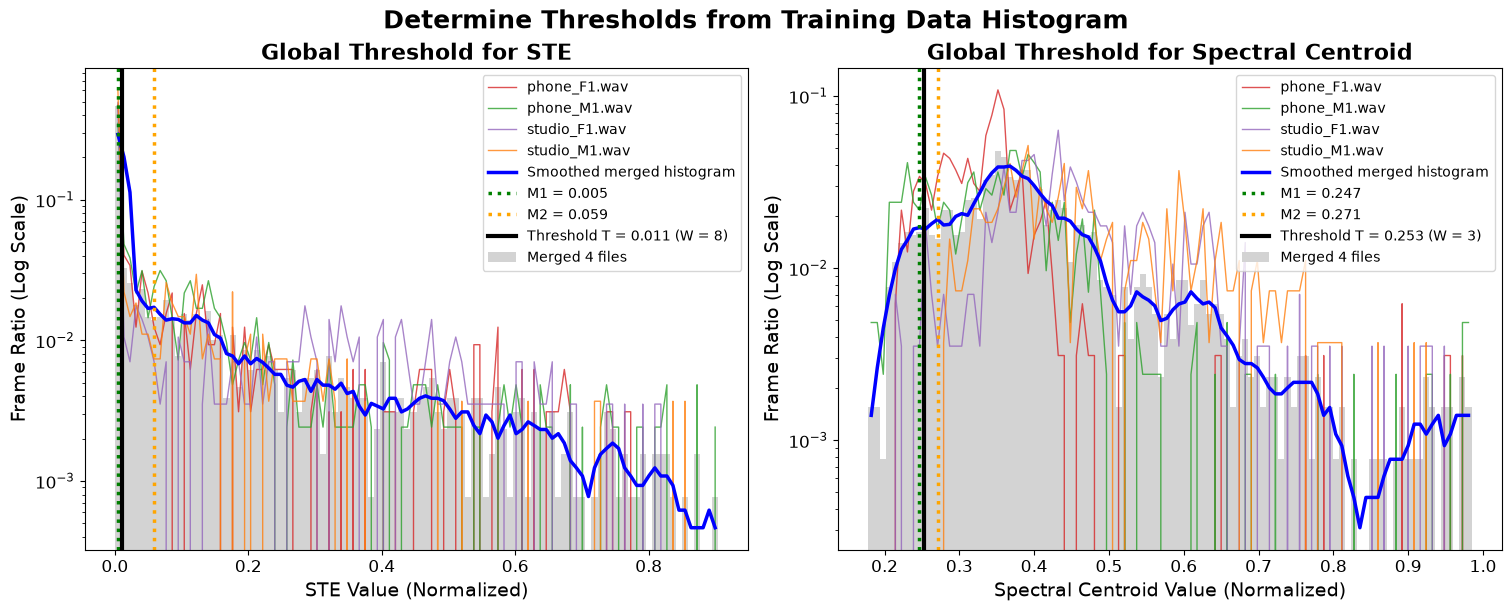


[OPTIMAL THRESHOLDS] T1 (STE) = 0.01055 | T2 (SC) = 0.25277 | T1_high = 0.05 | hang = 5 | shrink = 0


In [14]:
# Histogram figure (STE and SC)
save_histogram_figure(model)

# Learned thresholds and post-processing parameters
print(f"\n[OPTIMAL THRESHOLDS] T1 (STE) = {model['T1']:.5f} | T2 (SC) = {model['T2']:.5f} | "
      f"T1_high = {model['T1_high']} | hang = {model['hang']} | "
      f"shrink = {model.get('shrink', 0)}")

#### Comment on Figure 1 — training histograms and thresholds
Training files: `phone_F1`, `phone_M1`, `studio_F1`, `studio_M1`. Training MAE = 11.25 ms.

- **STE panel (left) — threshold is sensible.** The histogram is dominated by one very sharp spike at the far left (smoothed value about 0.3 of all frames, at STE ≈ 0.005): the silence / noise frames, so $M_1$ = 0.005 is reliable. The speech frames do not form a second clear mode; they spread over a long, slowly decaying tail from about 0.1 up to 0.9, and $M_2$ = 0.059 is only a weak shoulder. With $W = 8$ the threshold $T_1 = (8 \cdot 0.005 + 0.059)/9 \approx 0.011$ sits right at the foot of the silence spike, so almost everything above the noise floor is accepted as speech.
- **SC panel (right) — threshold is weak.** The histogram is broad and noisy with one wide mode around 0.35–0.4 (smoothed value about 0.04). $M_1$ = 0.247 and $M_2$ = 0.271 are two small local peaks on its rising left flank, only 0.024 apart, so $T_2$ = 0.253 ($W = 3$) lies at the lower edge of the distribution (the lowest SC values are about 0.18). The reason is the "first two peaks" rule: it picks the two left-most peaks, not the two largest modes. In practice $T_2$ rejects only frames with a very low centroid; silence and speech are *not* separated by SC (see Figures 2–5, where SC in silence is often high, or exactly 0 for digital silence).
- **Consequence.** STE does most of the work. Many voiced frames have a low centroid (SC < $T_2$), so the grid search chose $T1_{high}$ = 0.05: frames with STE above 0.05 are accepted as speech whatever their SC. Together with hangover = 5 frames and shrink = 0, this explains the small test errors even though the SC histogram is not truly bimodal.
- **Noise.** The thin per-file curves are jagged, especially in the tails, because each file has only a few hundred frames and the log axis magnifies sparsely filled bins; only the merged histogram (grey bars, blue line) is used.

### 9.3 Testing (Figures 2–5)
Each test file is processed in its own cell and followed by a comment on its figure. In every figure the top panel is STE with $T_1$, the middle panel is SC with $T_2$, and the bottom panel is the waveform with the ground-truth boundaries (red) and the detected boundaries (blue, dashed). All errors below are in milliseconds and, because the frame shift is 10 ms, they are always multiples of 10 ms.

In [15]:
print("--- STARTING TESTING PHASE ---")
test_dir = find_data_dir(TEST_DIR)
print(f"Testing folder: {test_dir}\n")

# file name -> (file name, #GT bounds, #Alg bounds, MAE, RMSE); filled by the cells below
results = {}

--- STARTING TESTING PHASE ---
Testing folder: c:\Users\Admin\OneDrive - The University of Technology\Máy tính\code\DUT\XLTHS\25-Phân đoạn tín hiệu tiếng nói-khoảng lặng\TinHieuKiemThu



#### 9.3.1 `phone_F2.wav` (Figure 2)

[phone_F2.wav]
  - Ground truth (from .lab) : [[1.02, 4.04]]
  - Algorithm (detected)     : [[1.05, 4.03]]
--------------------------------------------------


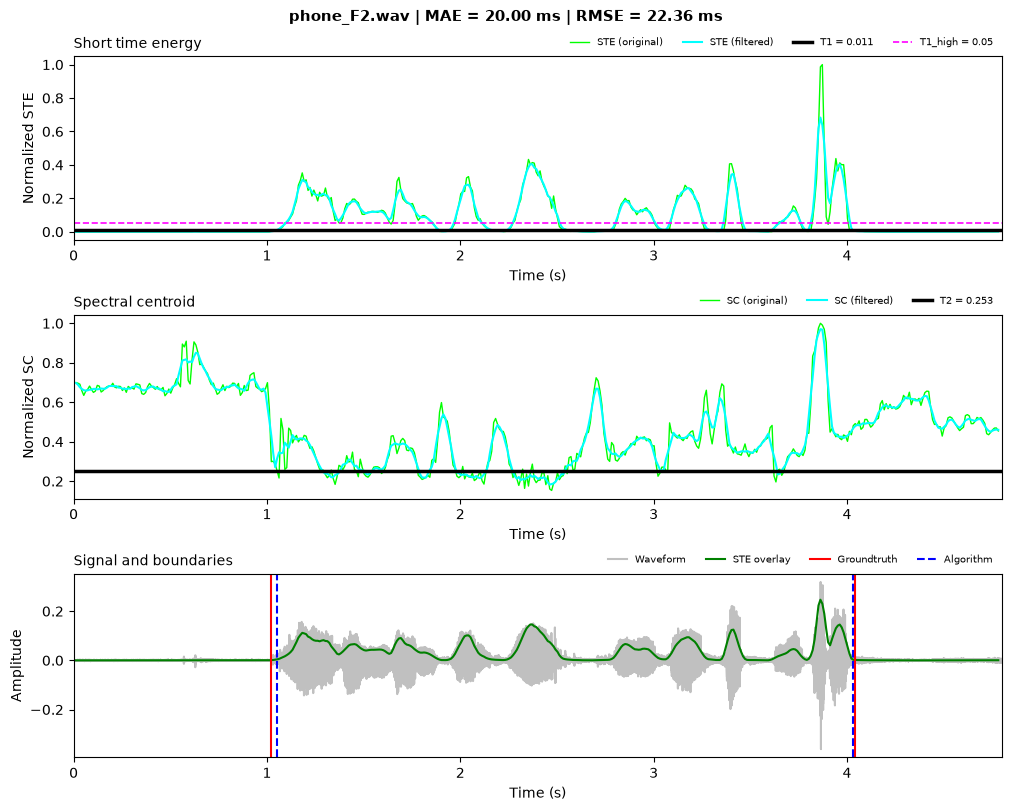

In [16]:
results["phone_F2.wav"] = test_file(model, os.path.join(test_dir, "phone_F2.wav"))

#### Comment on Figure 2 — `phone_F2.wav` (MAE = 20.00 ms, RMSE = 22.36 ms)
- **Verdict: correct, small error.** One speech segment is found, with both boundaries and no missing or extra segment (2 ground-truth vs 2 detected boundaries). This is the largest error of the four test files.
- **Error size and place.** The *start* is detected at 1.05 s instead of 1.02 s (30 ms late, 3 frames); the *end* at 4.03 s instead of 4.04 s (10 ms early, 1 frame). In the bottom panel the blue dashed line is visibly right of the red line at about 1.0 s, while the two lines almost coincide at about 4.04 s.
- **Why.** The onset at about 1.0 s is soft: the waveform starts with a very low amplitude and STE leaves zero only gradually (top panel, 1.0 → 1.2 s), so the first frames after the labelled start are still close to the silence floor and fail the very low threshold $T_1$ = 0.011. The labeller marked the earliest audible onset, whereas the detector needs a few frames of rising energy; the constant start / end offsets learned on the training set cannot compensate for a file-specific weak onset. The end is accurate because the last burst (STE and SC peak at about 3.87 s) is followed by a sharp fall to silence.
- **Also visible.** (1) Around 0.58 s SC jumps to about 0.9 but STE stays near zero, and the waveform shows only a tiny blip; the STE condition correctly prevents a false start there. (2) STE drops close to zero between syllables (for example around 2.6 s and 3.6 s), but these pauses are shorter than `MIN_SILENCE_MS` = 200 ms and are filled, so no false internal boundary appears. (3) SC is high (about 0.7) in the silence before speech, so only STE separates silence from speech here.

#### 9.3.2 `phone_M2.wav` (Figure 3)

[phone_M2.wav]
  - Ground truth (from .lab) : [[0.53, 2.52]]
  - Algorithm (detected)     : [[0.52, 2.53]]
--------------------------------------------------


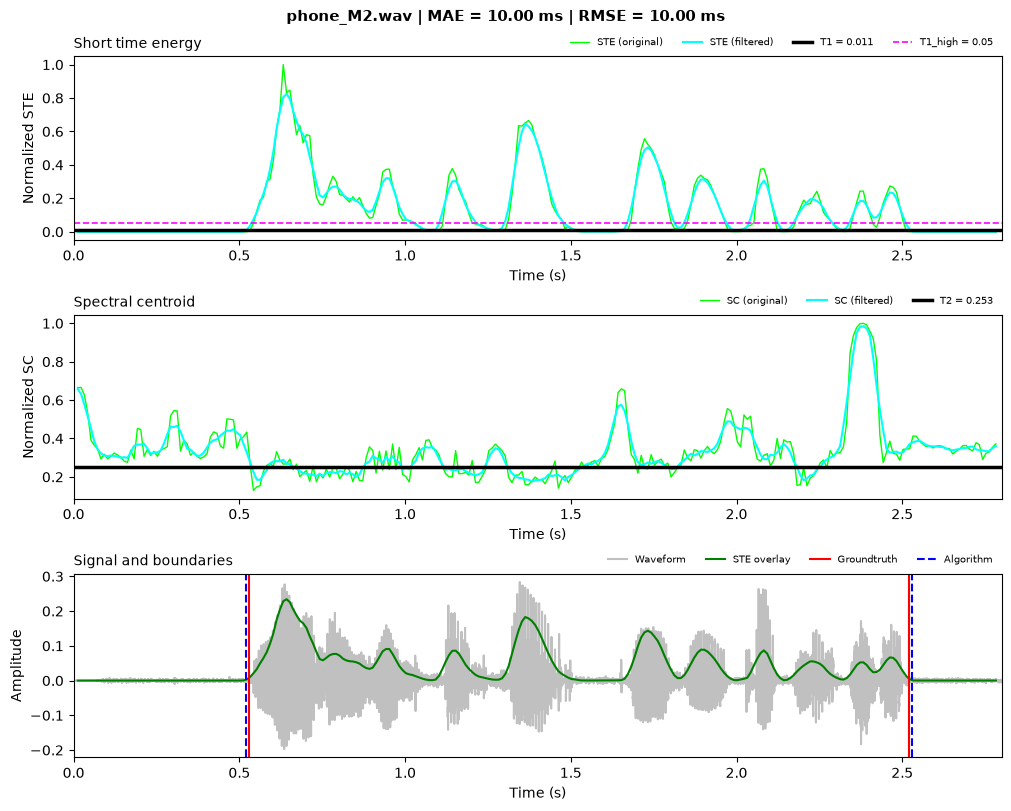

In [17]:
results["phone_M2.wav"] = test_file(model, os.path.join(test_dir, "phone_M2.wav"))

#### Comment on Figure 3 — `phone_M2.wav` (MAE = 10.00 ms, RMSE = 10.00 ms)
- **Verdict: correct, very small error.** One segment, both boundaries found, nothing missing or extra.
- **Error size and place.** The *start* is 0.52 s vs 0.53 s (10 ms early) and the *end* is 2.53 s vs 2.52 s (10 ms late), so the detected segment is 20 ms wider than the label. The red and blue lines almost overlap at about 0.5 s (left) and about 2.5 s (right) in the bottom panel. The error equals exactly one frame shift, i.e. the resolution limit of the method.
- **Why.** A 25 ms frame that only partly covers the onset (or the fading end) already carries enough energy to exceed $T_1$ = 0.011, so the decision switches up to one frame before the labelled start and one frame after the labelled end. Such a ±1-frame difference is also within the usual uncertainty of manual labels.
- **Also visible.** (1) Between syllables STE falls close to zero (for example around 1.2 s, 1.6 s and 2.1 s) but these gaps are shorter than 200 ms and are bridged. (2) From about 0.5 s to 1.6 s SC is mostly at or below $T_2$ = 0.253, so the $T1_{high}$ = 0.05 override is what keeps these voiced frames as speech. (3) SC in the leading and trailing silence (about 0.3–0.4) is above $T_2$, so again only STE rejects silence.

#### 9.3.3 `studio_F2.wav` (Figure 4)

[studio_F2.wav]
  - Ground truth (from .lab) : [[0.77, 2.37]]
  - Algorithm (detected)     : [[0.76, 2.35]]
--------------------------------------------------


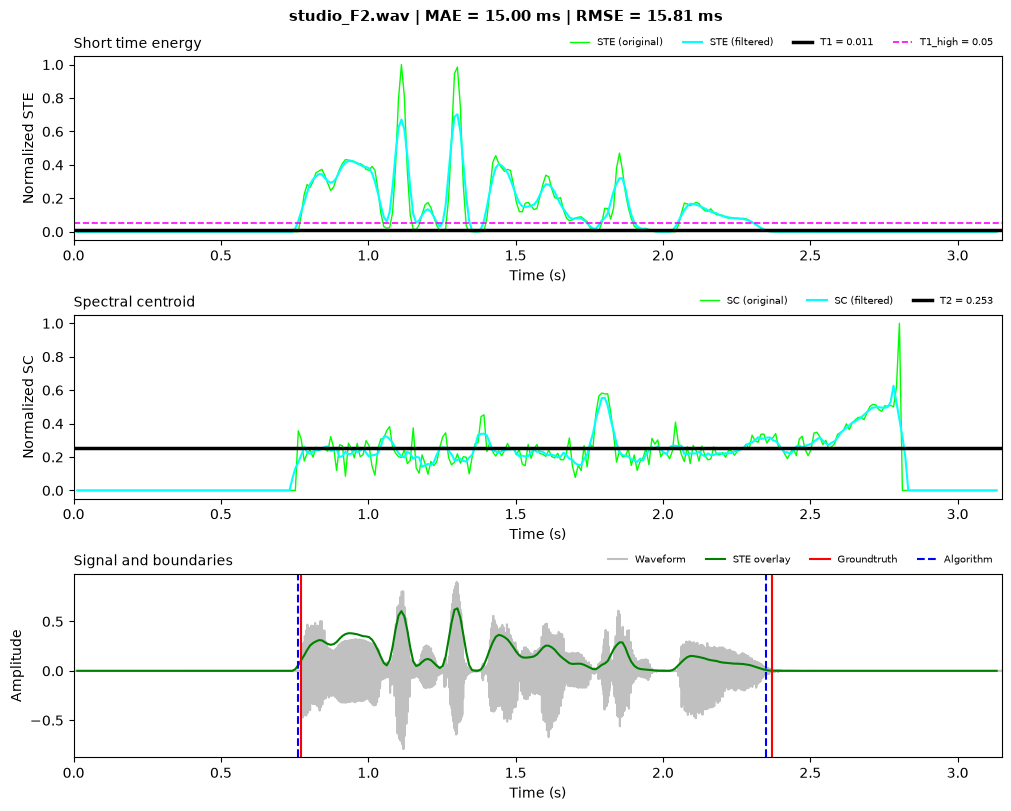

In [18]:
results["studio_F2.wav"] = test_file(model, os.path.join(test_dir, "studio_F2.wav"))

#### Comment on Figure 4 — `studio_F2.wav` (MAE = 15.00 ms, RMSE = 15.81 ms)
- **Verdict: correct, small error.** One segment, both boundaries found, nothing missing or extra.
- **Error size and place.** The *start* is 0.76 s vs 0.77 s (10 ms early) and the *end* is 2.35 s vs 2.37 s (20 ms early). The start pair at about 0.77 s overlaps in the bottom panel; at about 2.35 s the blue dashed line is visibly left of the red line, so the end is the larger error and the detected segment is slightly too short on the right.
- **Why.** The utterance ends with a long, quiet fade-out: STE decays slowly from about 0.1 at 2.2 s to almost zero at about 2.35 s (top panel). On such a gentle slope the last ~20 ms that the labeller still counted as speech lie at an energy close to the silence floor, so the smoothed STE falls below $T_1$ slightly before the labelled end.
- **Also visible.** (1) SC is exactly 0 in the digital silence before 0.73 s and after 2.82 s. (2) During speech SC is mostly around 0.2–0.25, i.e. *below* $T_2$ = 0.253; this file is a clear example of why the $T1_{high}$ = 0.05 override is needed, because it keeps the speech frames that the SC test would reject. (3) After 2.35 s SC rises to 0.5–0.6 while STE is about zero; this residual low-energy part is correctly not added to the segment.

#### 9.3.4 `studio_M2.wav` (Figure 5)

[studio_M2.wav]
  - Ground truth (from .lab) : [[0.45, 1.93]]
  - Algorithm (detected)     : [[0.46, 1.92]]
--------------------------------------------------


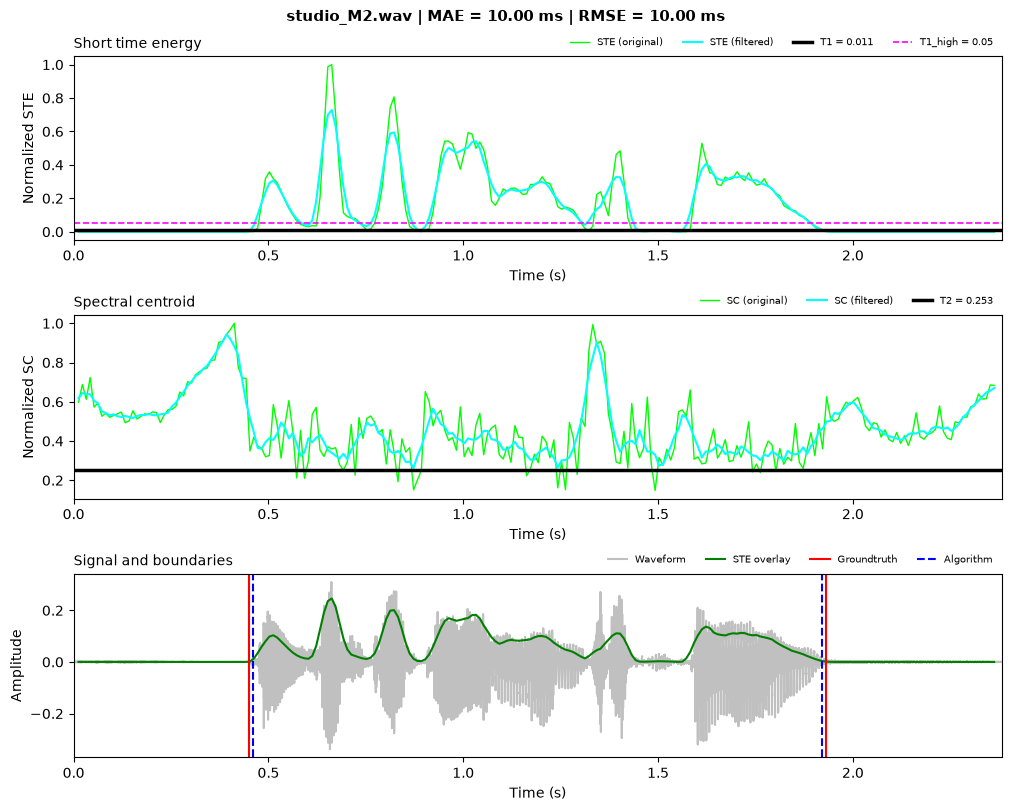

In [19]:
results["studio_M2.wav"] = test_file(model, os.path.join(test_dir, "studio_M2.wav"))

#### Comment on Figure 5 — `studio_M2.wav` (MAE = 10.00 ms, RMSE = 10.00 ms)
- **Verdict: correct, very small error.** One segment, both boundaries found, nothing missing or extra.
- **Error size and place.** The *start* is 0.46 s vs 0.45 s (10 ms late) and the *end* is 1.92 s vs 1.93 s (10 ms early), so the detected segment is 20 ms narrower than the label (the opposite sign to Figure 3). The red and blue lines are only one frame apart at about 0.45 s (left) and about 1.93 s (right).
- **Why.** The onset is a fast rise (STE reaches about 0.3 by 0.5 s) and the end is a smooth decay, so the detector is off by one frame at most: the smoothed STE of the first labelled frame has not crossed $T_1$ yet, and the last labelled frame is already just below it. With a 10 ms frame shift this is the smallest possible non-zero error.
- **Also visible.** (1) Just before the onset SC climbs to about 0.9 (around 0.4 s) while STE is still near zero, likely a breath or noise before the speech; the STE condition prevents a false early start. (2) The longest internal pause (about 1.45–1.58 s, STE close to zero, roughly 150 ms) is shorter than 200 ms and is filled, so the file stays one segment. (3) SC stays above $T_2$ for almost the whole file, including the silences, so silence is again rejected by STE only.

### 9.4 Summary table
MAE / RMSE of each test file and their average — the numbers to report in the comparison table of the slides.

In [20]:
print_test_summary(list(results.values()))


[TESTING RESULTS]
---------------------------------------------------------------------------
File                             #GT bounds  #Alg bounds   MAE(ms)  RMSE(ms)
---------------------------------------------------------------------------
phone_F2.wav                              2            2     20.00     22.36
phone_M2.wav                              2            2     10.00     10.00
studio_F2.wav                             2            2     15.00     15.81
studio_M2.wav                             2            2     10.00     10.00
AVERAGE                                                      13.75     14.54
